# Partial Autocorrelation (Tự tương quan từng phần)




## Partial Autocorrelation (Tự tương quan từng phần) là gì?



Chúng ta có thể bắt đầu bằng cách giải thích Partial Correlation (Tương quan từng phần). Đây là Correlation (Tương quan) giữa hai biến ngẫu nhiên trong khi kiểm soát ảnh hưởng của một (hoặc nhiều) biến ngẫu nhiên khác ảnh hưởng đến các biến ban đầu mà chúng ta đang tương quan.

Giả sử chúng ta có ba biến ngẫu nhiên X, Y và Z. Partial Correlation (Tương quan từng phần) giữa X và Y, loại trừ ảnh hưởng của Z, về mặt toán học là:


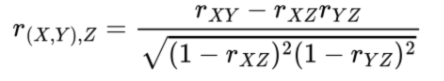

Trong đó r là Correlation Coefficient (Hệ số tương quan) có giá trị từ -1 đến 1.

Partial Autocorrelation (Tự tương quan từng phần) sau đó chỉ đơn giản là Partial Correlation (Tương quan từng phần) của Time Series (Chuỗi thời gian) ở hai trạng thái khác nhau trong thời gian. Đi xa hơn một bước, đó là Correlation (Tương quan) giữa Time Series (Chuỗi thời gian) ở hai Lag (Độ trễ) khác nhau không xem xét ảnh hưởng của bất kỳ Lag trung gian nào. Ví dụ, Partial Autocorrelation (Tự tương quan từng phần) cho Lag (Độ trễ) 2 chỉ là Correlation (Tương quan) mà Lag 1 không giải thích được.


## Tại sao nó hữu ích?



Không giống như Autocorrelation (Tự tương quan), Partial Autocorrelation (Tự tương quan từng phần) không có nhiều ứng dụng cho Time Series Analysis (Phân tích chuỗi thời gian). Tuy nhiên, tác động chính và rất quan trọng của nó là khi xây dựng các Forecasting Model (Mô hình dự báo).

PACF được sử dụng để ước tính Number/Order (Số/Thứ tự) của Autoregressive Component (Thành phần tự hồi quy) khi Fitting (Khớp) các Model Autoregressive, ARMA hoặc ARIMA như được xác định bởi Box-Jenkins Procedure (Quy trình Box-Jenkins). Các Model (Mô hình) này có lẽ được sử dụng nhiều nhất và thường cung cấp kết quả tốt nhất khi Training (Huấn luyện) một Forecasting Model (Mô hình dự báo).


## Ví dụ Python


In [1]:
# Import các thư viện
import plotly.express as px
import pandas as pd
from statsmodels.graphics.tsaplots import plot_pacf
import matplotlib.pyplot as plt


In [2]:
# Đọc dữ liệu
data = pd.read_csv('AirPassengers.csv', index_col=0)
data.index = pd.to_datetime(data.index)

# Vẽ biểu đồ dữ liệu
fig = px.line(data, x=data.index, y='#Passengers',
              labels=({'#Passengers': 'Passengers', 'Month': 'Date'}))

fig.update_layout(template="simple_white", font=dict(size=18),
                  title_text='Airline Passengers', width=650, title_x=0.5, height=400)

fig.show()


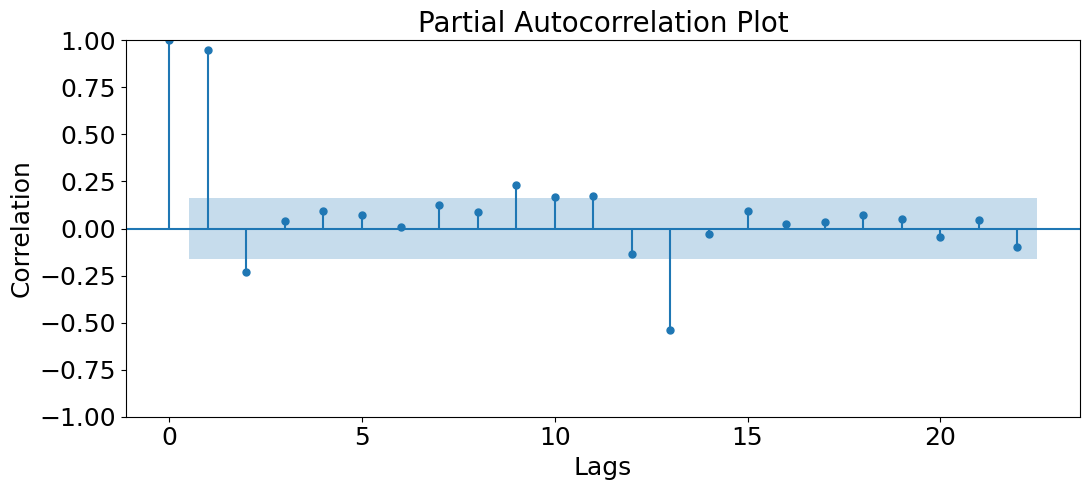

In [3]:
# Vẽ biểu đồ partial autocorrelation
plt.rc("figure", figsize=(11,5))
plot_pacf(data['#Passengers'], method='ywm')
plt.xlabel('Lags', fontsize=18)
plt.ylabel('Correlation', fontsize=18)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.title('Partial Autocorrelation Plot', fontsize=20)
plt.tight_layout()
plt.show()


Chúng ta thấy rằng Lag 1 có Correlation (Tương quan) cao và có các Lag có Correlation (Tương quan) cao khác sau này trong thời gian có thể do ảnh hưởng của Seasonality (Tính mùa vụ).

Tuy nhiên, từ biểu đồ này khá không rõ ràng chúng ta sẽ chọn bao nhiêu Autoregressor (Tự hồi quy) nếu chúng ta đang xây dựng một Forecasting Model (Mô hình dự báo). Do đó, thường được khuyến nghị chỉ cần thực hiện Grid-Search (Tìm kiếm lưới) trên các Parameter (Tham số) có thể sử dụng các Modeling Package (Thư viện mô hình) như auto arima.



Vùng màu xanh là nơi các Lag (Độ trễ) không còn có ý nghĩa thống kê. Chúng ta thường chọn Number of Autoregressor (Số lượng tự hồi quy) bằng cách xem có bao nhiêu trong số chúng nằm trên vùng màu xanh.
